# Credit Scoring com XGBoost
Objetivo: Modelagem preditiva para estimativa de probabilidade de adimplência ou inadimplência.

### Import de bibliotecas

In [2]:
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import shap
from IPython.display import display


### 1. Carga dos dados e ETL

In [ ]:
file_path = r"C:\Users\bruna\Downloads\GitHub Projeto\data\default_credit_card_clients.csv"
df = pd.read_csv(file_path)

print(f"{df.shape[0]} linhas e {df.shape[1]} colunas.")

Base carregada com 30000 linhas e 25 colunas.


In [61]:
#df.dtypes

In [ ]:
df.columns = [c.lower().strip().replace(".", "_") for c in df.columns]

# Rename do target
target_col = [c for c in df.columns if "default" in c][0]
df.rename(columns={target_col: "target"}, inplace=True)


In [ ]:
#Visualização dos primeiros 5 registros da base
df.head(5) 

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,target
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 2. Análise Exploratória dos Dados (EDA)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         30000 non-null  int64  
 1   limit_bal  30000 non-null  float64
 2   sex        30000 non-null  int64  
 3   education  30000 non-null  int64  
 4   marriage   30000 non-null  int64  
 5   age        30000 non-null  int64  
 6   pay_0      30000 non-null  int64  
 7   pay_2      30000 non-null  int64  
 8   pay_3      30000 non-null  int64  
 9   pay_4      30000 non-null  int64  
 10  pay_5      30000 non-null  int64  
 11  pay_6      30000 non-null  int64  
 12  bill_amt1  30000 non-null  float64
 13  bill_amt2  30000 non-null  float64
 14  bill_amt3  30000 non-null  float64
 15  bill_amt4  30000 non-null  float64
 16  bill_amt5  30000 non-null  float64
 17  bill_amt6  30000 non-null  float64
 18  pay_amt1   30000 non-null  float64
 19  pay_amt2   30000 non-null  float64
 20  pay_amt3   30000 

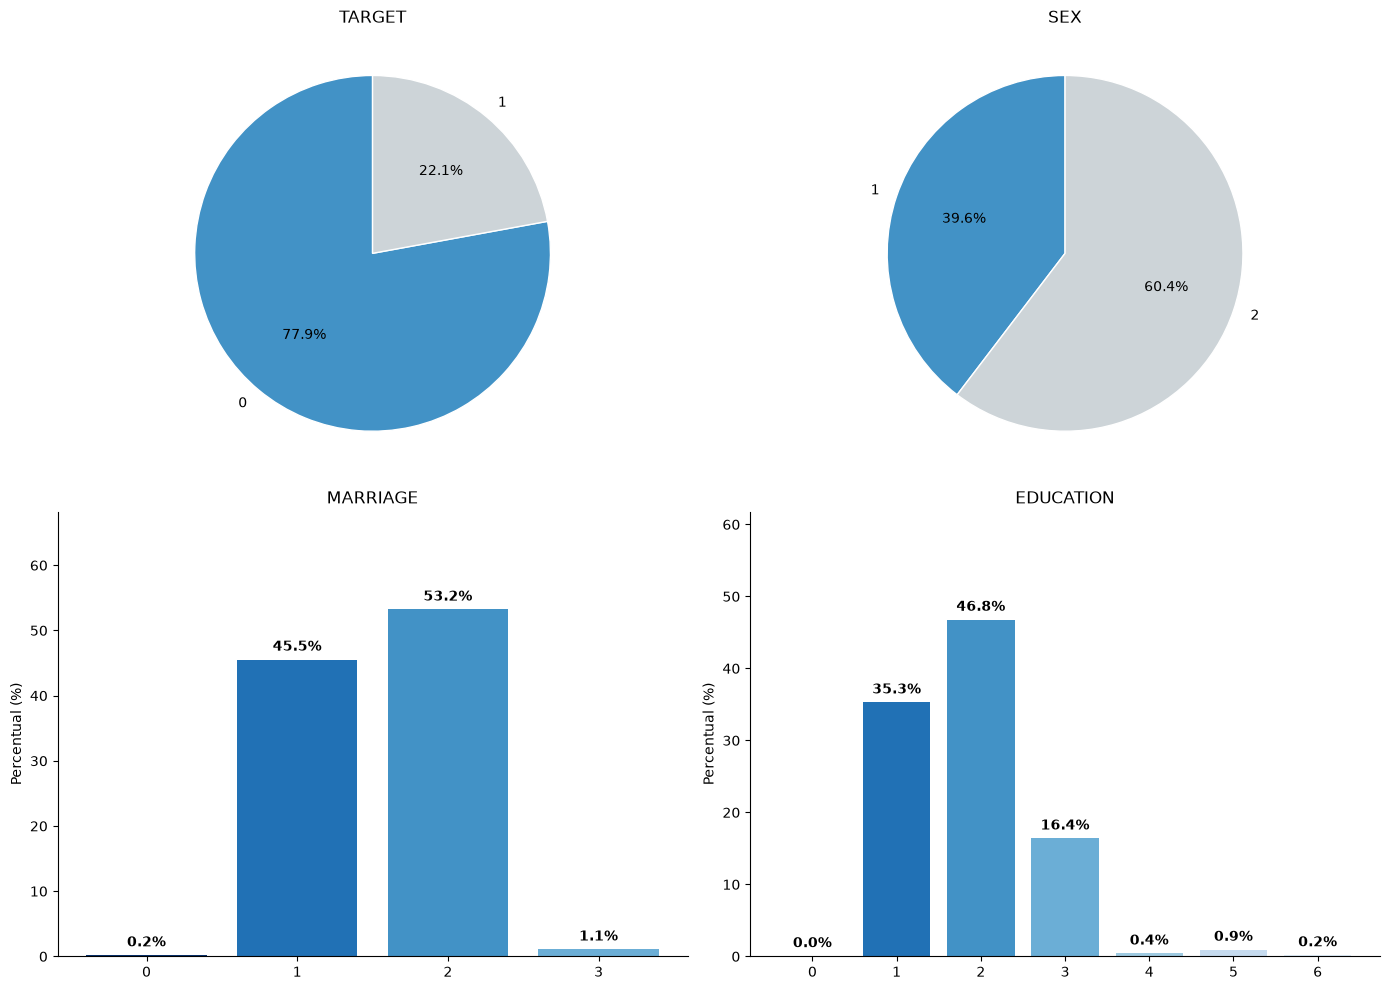

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Paletas de cores em tons azuis
cores_pizza = ['#4292c6', "#cdd4d8"]
cores_barras = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7']

# Gráficos de pizza para as variáveis target e sex
colunas_pizza = ['target', 'sex']
for i, col in enumerate(colunas_pizza):
    if col in df.columns:
        contagem = df[col].value_counts().sort_index()
        axes[i].pie(
            contagem, 
            labels=contagem.index, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=cores_pizza,
            wedgeprops={'edgecolor': 'white'}
        )
        axes[i].set_title(f'{col.upper()}', fontsize=12)

# Gráficos de barras para as variáveis marriage e education
colunas_barras = ['marriage', 'education']
for i, col in enumerate(colunas_barras):
    idx = i + 2  # Direciona para os dois eixos inferiores da grade
    if col in df.columns:
        percentuais = df[col].value_counts(normalize=True).sort_index() * 100
        
        bars = axes[idx].bar(
            percentuais.index.astype(str), 
            percentuais.values, 
            color=cores_barras[:len(percentuais)], # Ajusta a quantidade de azuis ao número de barras
            edgecolor='none' # Remove a moldura preta das barras
        )
        
        axes[idx].set_title(f'{col.upper()}', fontsize=12)
        axes[idx].set_ylabel('Percentual (%)')
        axes[idx].set_ylim(0, percentuais.max() + 15) 
        
        # Remove as linhas de enquadramento superior e direita do gráfico
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
        
        for bar in bars:
            height = bar.get_height()
            axes[idx].annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
#Análise de valores máximos e mínimos:
cols_faturas = [f'bill_amt{i}' for i in range(1, 7)]
cols_pagamentos = [f'pay_amt{i}' for i in range(1, 7)]
cols_financeiras = ['limit_bal'] + cols_faturas + cols_pagamentos

print("=== Mínimos e Máximos Financeiros ===")
resumo_financeiro = df[cols_financeiras].agg(['min', 'max']).T
display(resumo_financeiro)

print("\n=== Idade Mínima e Máxima por Sexo ===")
idade_resumo = df.groupby('sex')['age'].agg(['min', 'max']).reset_index()
idade_resumo.rename(columns={'sex': 'Sexo', 'min': 'Mínima', 'max': 'Máxima'}, inplace=True)
display(idade_resumo)

=== Mínimos e Máximos Financeiros ===


,min,max
limit_bal,10000.0,1000000.0
bill_amt1,-165580.0,964511.0
bill_amt2,-69777.0,983931.0
bill_amt3,-157264.0,1664089.0
bill_amt4,-170000.0,891586.0
bill_amt5,-81334.0,927171.0
bill_amt6,-339603.0,961664.0
pay_amt1,0.0,873552.0
pay_amt2,0.0,1684259.0
pay_amt3,0.0,896040.0



=== Idade Mínima e Máxima por Sexo ===


,Sexo,Mínima,Máxima
0,1,21,79
1,2,21,75


### 3. Feature Engineering

In [32]:
df_modelagem = df.copy()

# Padronização dos nomes das variáveis
df_modelagem.columns = [c.lower().strip().replace(".", "_") for c in df_modelagem.columns]
if "id" in df_modelagem.columns:
    df_modelagem.drop(columns=["id"], inplace=True)

# Variáveis de taxas de utilização
for i in range(1, 7):
    bill = f"bill_amt{i}"
    if bill in df_modelagem.columns:
        df_modelagem[f"utilization_rate_{i}"] = df_modelagem[bill] / (df_modelagem["limit_bal"] + 1.0)

# Variáveis de proporção paga
for i in range(1, 6):
    pay = f"pay_amt{i}"
    bill_prev = f"bill_amt{i+1}"
    if pay in df_modelagem.columns and bill_prev in df_modelagem.columns:
        df_modelagem[f"payment_ratio_{i}"] = df_modelagem[pay] / np.maximum(df_modelagem[bill_prev], 1.0)

# Variáveis de atraso máximo
pay_cols = [c for c in df_modelagem.columns if c.startswith("pay_") and not c.startswith("pay_amt")]
if pay_cols:
    df_modelagem["max_delay_months"] = df_modelagem[pay_cols].max(axis=1)


novas_vars = [c for c in df_modelagem.columns if "rate" in c or "ratio" in c or "max" in c]
print(f"Novas variáveis criadas: {novas_vars}")

Novas variáveis criadas: ['utilization_rate_1', 'utilization_rate_2', 'utilization_rate_3', 'utilization_rate_4', 'utilization_rate_5', 'utilization_rate_6', 'payment_ratio_1', 'payment_ratio_2', 'payment_ratio_3', 'payment_ratio_4', 'payment_ratio_5', 'max_delay_months']


### 4. Treino e Avaliação do XGBoost

In [ ]:
#Teste modelagem com todas as variáveis
X = df_modelagem.drop(columns=["target"])
y = df_modelagem["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=30
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
#Análise da importancia das variáveis
tabela_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'Feature_Importance': model.feature_importances_
}).sort_values(by='Feature_Importance', ascending=False)

display(tabela_importancia)

,Variavel,Feature_Importance
34,max_delay_months,0.431594
5,pay_0,0.127891
6,pay_2,0.027071
19,pay_amt3,0.025154
7,pay_3,0.021488
18,pay_amt2,0.020672
0,limit_bal,0.018931
24,utilization_rate_2,0.018774
8,pay_4,0.017689
11,bill_amt1,0.016958


In [ ]:
#Retreinamento do modelo após exclusão das variáveis de baixa importância
colunas_para_remover = [
    "sex", "education", "marriage", "age",
    "payment_ratio_5", "pay_amt5", "bill_amt3", "bill_amt6",
    "utilization_rate_4", "utilization_rate_6", "utilization_rate_5", "bill_amt4"
]

df_modelagem_final = df_modelagem.drop(columns=colunas_para_remover)

X = df_modelagem_final.drop(columns=["target"])
y = df_modelagem_final["target"]

### 5. Métricas

Algumas métricas foram escolhidas para avaliar a performance do modelo: 

**KS2 e AUC-ROC:** A Estatística KS (Kolmogorov-Smirnov) analisa a distância máxima entre as distribuições acumuladas de bons e maus pagadores. O modelo atingiu um KS2 acima de 42%, um valor considerado bom para os padrões do mercado de crédito, garantindo boa capacidade de isolar perfis inadimplentes nos decis mais altos da carteira. Além disso, a métrica AUC-ROC foi igual a 0.78, mostrando que o modelo oferece segurança para otimizar as políticas de aprovação e rejeição.

**SHAP:** O uso da biblioteca SHAP (*SHapley Additive exPlanations*) garante a explicabilidade global e local do modelo XGBoost. Isso permite que seja compreendido exatamente quais fatores, como atraso máximo em meses ou taxa de utilização do limite, aumentaram ou reduziram a probabilidade de *default* de cada cliente.

AUC-ROC Score : 0.7816
Estatística KS2: 0.4238

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.88      0.78      0.83      5841
           1       0.45      0.64      0.53      1659

    accuracy                           0.75      7500
   macro avg       0.67      0.71      0.68      7500
weighted avg       0.79      0.75      0.76      7500


Tabela KS por Decis de Risco:


,total,bads,goods,cum_bads,cum_goods,ks_decil
decil,,,,,,
9,750,530,220,0.3195,0.0377,0.2818
8,748,314,434,0.5087,0.1120,0.3968
7,752,199,553,0.6287,0.2066,0.4220
6,750,133,617,0.7089,0.3123,0.3966
5,750,142,608,0.7945,0.4164,0.3781
4,750,113,637,0.8626,0.5254,0.3371
3,750,81,669,0.9114,0.6400,0.2714
2,750,71,679,0.9542,0.7562,0.1980
1,750,50,700,0.9843,0.8760,0.1083



Valores SHAP...


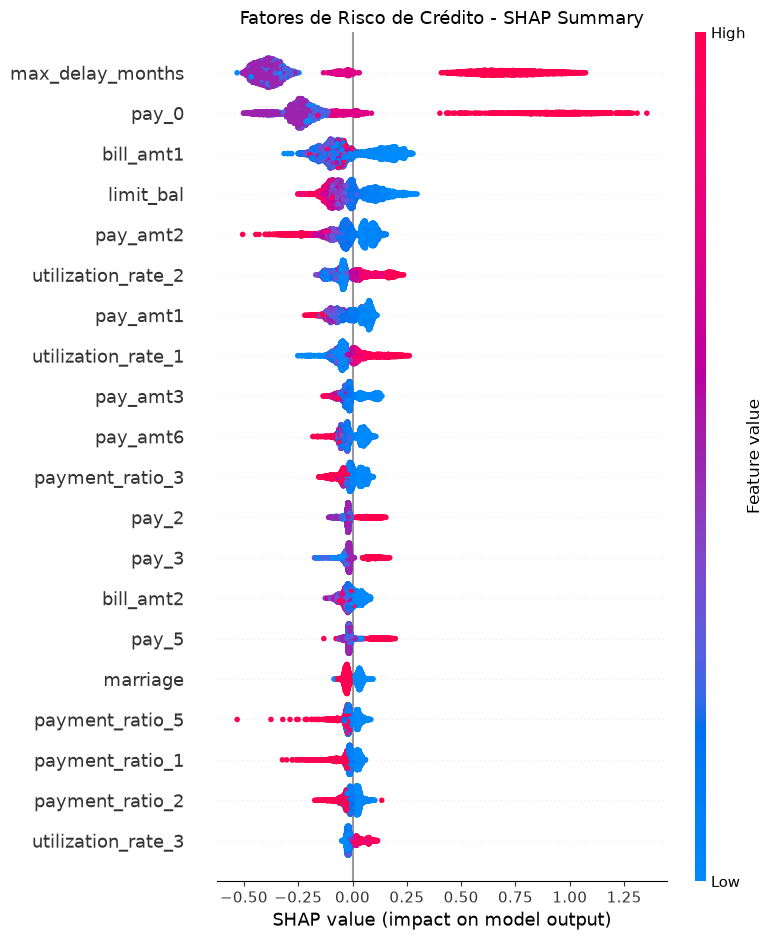

In [33]:
# Avaliação de performance
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

# KS2
goods = y_pred_proba[y_test == 0]
bads = y_pred_proba[y_test == 1]
ks_stat, _ = ks_2samp(bads, goods)

print("=" * 45)
print(f"AUC-ROC Score : {auc:.4f}")
print(f"Estatística KS2: {ks_stat:.4f}")
print("=" * 45)
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Tabela Decis do KS - Padrão em análise de risco de crédito
df_ks = pd.DataFrame({'target': y_test, 'proba': y_pred_proba})
df_ks['decil'] = pd.qcut(df_ks['proba'], 10, labels=False, duplicates='drop')

ks_table = df_ks.groupby('decil').agg(
    total=('target', 'count'),
    bads=('target', 'sum')
).sort_index(ascending=False) 

ks_table['goods'] = ks_table['total'] - ks_table['bads']

ks_table['cum_bads'] = ks_table['bads'].cumsum() / ks_table['bads'].sum()
ks_table['cum_goods'] = ks_table['goods'].cumsum() / ks_table['goods'].sum()

ks_table['ks_decil'] = np.abs(ks_table['cum_bads'] - ks_table['cum_goods'])

print("\nTabela KS por Decis de Risco:")
display(ks_table[['total', 'bads', 'goods', 'cum_bads', 'cum_goods', 'ks_decil']].round(4))

# Análise SHAP
print("\nValores SHAP...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Fatores de Risco de Crédito - SHAP Summary", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

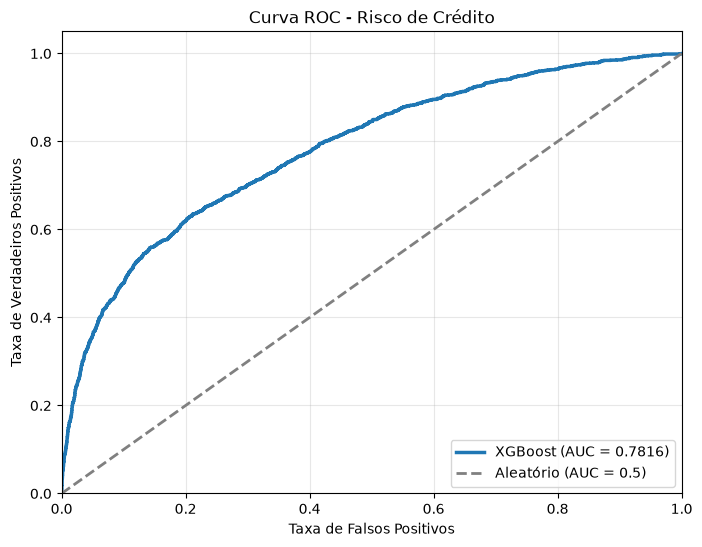

In [37]:
# Taxa de FP e a VP
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Aleatório (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Risco de Crédito')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()